In [2]:
import numpy as np
import pandas as pd
import torch
import gensim


print(torch.__version__)
print(gensim.__version__)

2.7.1+cu118
4.4.0


In [3]:
chat_df = pd.read_csv('~/data/ChatbotData.csv')
chat_df

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0
...,...,...,...
11818,훔쳐보는 것도 눈치 보임.,티가 나니까 눈치가 보이는 거죠!,2
11819,훔쳐보는 것도 눈치 보임.,훔쳐보는 거 티나나봐요.,2
11820,흑기사 해주는 짝남.,설렜겠어요.,2
11821,힘든 연애 좋은 연애라는게 무슨 차이일까?,잘 헤어질 수 있는 사이 여부인 거 같아요.,2


In [4]:
import re 
# 전처리 함수
def preprocess_sentence(sentence):
  # 입력받은 sentence 양쪽 공백을 제거
  sentence = sentence.lower().strip()

  # 단어와 구두점(punctuation) 사이의 거리를 만듭니다.
  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
  sentence = re.sub(r'[" "]+', " ", sentence)

  # (한글, 영어, 슛자, ".", "?", "!", ",")를 제외한 모든 문자를 공백인 ' '로 대체합니다.
  sentence = re.sub(r"[^ㄱ-ㅎㅏ-ㅣ가-힣a-zA-Z0-9?.!,]+", " ", sentence)
  sentence = sentence.strip()
  return sentence

In [5]:
from tqdm import tqdm

for i in tqdm(range(len(chat_df))):

    chat_df.loc[i, 'Q'] = preprocess_sentence(chat_df.loc[i, 'Q'])
    chat_df.loc[i, 'A'] = preprocess_sentence(chat_df.loc[i, 'A'])

chat_df.drop_duplicates(subset=['Q'], inplace=True)
chat_df.drop_duplicates(subset=['A'], inplace=True)
chat_df = chat_df.replace('', pd.NA)
chat_df = chat_df.dropna(how = 'any')
chat_df.reset_index(drop=True, inplace=True)

100%|██████████| 11823/11823 [00:11<00:00, 1067.76it/s]


In [6]:
chat_df

,Q,A,label
0,12시 땡 !,하루가 또 가네요 .,0
1,1지망 학교 떨어졌어,위로해 드립니다 .,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠 .,0
3,ppl 심하네,눈살이 찌푸려지죠 .,0
4,sd카드 망가졌어,다시 새로 사는 게 마음 편해요 .,0
...,...,...,...
7726,회식 중이라고 하는데 연락이 안돼 .,정신 없이 바쁠지도 몰라요 . 조금만 더 기다려보고 물어보는게 좋을 것 같아요 .,2
7727,후회 없이 사랑하고 싶어,진심으로 다가가 보세요 .,2
7728,훔쳐보는 것도 눈치 보임 .,티가 나니까 눈치가 보이는 거죠 !,2
7729,흑기사 해주는 짝남 .,설렜겠어요 .,2


문장의 최단 길이: 1
문장의 최장 길이: 57
문장의 평균 길이: 14


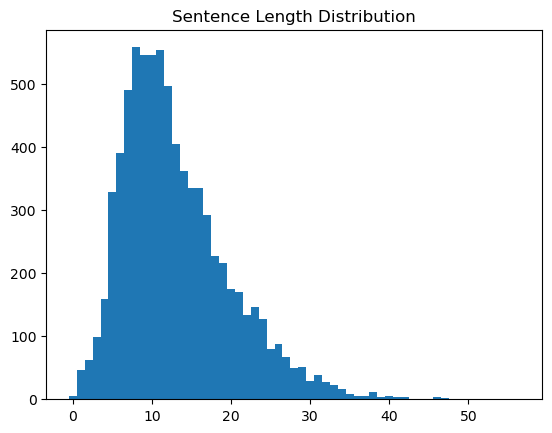

In [7]:
import matplotlib.pyplot as plt
min_len = 999
max_len = 0
sum_len = 0

for sen in chat_df['Q']:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

print("문장의 최단 길이:", min_len)
print("문장의 최장 길이:", max_len)
print("문장의 평균 길이:", sum_len // len(chat_df['Q']))

sentence_length = np.zeros((max_len), dtype=int)

for sen in chat_df['Q']:
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

In [8]:
def check_sentence_with_length(raw, length):
    count = 0

    for sen in raw:
        if len(sen) == length:
            print(sen)
            count += 1
            if count > 100: return

print( '길이가 1인 text 확인')
print('===Q====')
check_sentence_with_length(chat_df['Q'], 1)

print('===A===')
check_sentence_with_length(chat_df['A'], 1)

길이가 1인 text 확인
===Q====
야
음
왜
후
휴
===A===
네
음


In [9]:
check_sentence_with_length(chat_df['Q'], 57)

확실히 좋아하는 데도 관심 있는거 티 안내려고 선톡 안하고 일부러 늦게 보내고 그러는 사람도 있어요 ?


In [10]:
# 1이하 길이의 text 삭제
chat_df = chat_df[chat_df['Q'].str.len() > 1]
chat_df = chat_df[chat_df['A'].str.len() > 1]

#### Tranin/Validation split

In [11]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    chat_df,
    test_size=0.05,
    stratify=chat_df['label'],   # stratify 기준 column
    random_state=42
)

In [12]:
val_df

,Q,A,label
2237,키 왜 안 크지,신경쓰면 스트레스 받아요 .,0
2319,핸드폰 너무 많이 해,그래서 저를 만날 수 있죠 .,0
1059,무료 앱이 유료로 됐어,돈을 지불하고 이용할 가치가 있는지 따져보세요 .,0
21,가족들이랑 서먹해,다들 바빠서 이야기할 시간이 부족했나봐요 .,0
2844,남자 못믿겠어 .,믿게 할 남자가 생길 거예요 .,1
...,...,...,...
769,대청소 해야지,건강에도 좋겠네요 .,0
7283,좋아하는게 이렇게 힘들지 몰랐어 .,좋아하는 것 만큼 감정 소모가 큰 건 없어요 .,2
4329,이별한지 3일째네,이별은 실감이 안나나봐요 .,1
1130,밖에 안나가고 이렇게 살고 싶어,꼭 앞으로 나가야 하는 건 아니에요 .,0


### Augmentation

In [13]:
from gensim.models import KeyedVectors
from io import BytesIO
import zipfile
import urllib.request
import pickle
import os 

# 코드 출처: https://recipesds.tistory.com/entry/word2vec%EC%9D%84-gensim-4x-%EC%9A%A9%EC%9C%BC%EB%A1%9C-%EC%97%85%EA%B7%B8%EB%A0%88%EC%9D%B4%EB%93%9C-%ED%95%98%EB%8A%94-%EB%B2%95

wordvec_path = os.getenv('HOME') + '/work/transformer_chatbot/data/ko.bin'
converted_model_path = os.getenv('HOME') + '/work/transformer_chatbot/data/ko_w2v_format.bin'

''' 현재 인터넷에 공개되어 있는 kyubyong/word2vec 모델은 gensim 3x에서 개발되었고, binary format이 틀림
지금 현재 최신 gensim은 4.4이고, 이 모델 binary를 읽을 수 없음
왠만한 제안들이 python 3.8이하에 gensim 3x 를 사용하라고 제안하지만, 그러고 싶지 않음
그래서 객체에 그대로 불러드리는 것이 아니라, 순수 binary만 읽어들여서 그것을 객체에 넣은 후 다시 저장하는 방법을
구현함. '''

# 2. pickle 파일을 바이트 스트림으로 로드하고, 내부 데이터만 추출
with open(wordvec_path, 'rb') as f:
    file_bytes = BytesIO(f.read())
    unpickler = pickle.Unpickler(file_bytes, encoding='latin1')
    old_model_data = unpickler.load()

# 3. old_model_data에서 직접 벡터와 단어 목록 추출
word_vectors = old_model_data.syn0
word_key_to_index = {word: index for index, word in enumerate(old_model_data.index2word)}

# 4. 새로운 KeyedVectors 객체로 재구성
new_kv = KeyedVectors(vector_size=word_vectors.shape[1])
new_kv.add_vectors(list(word_key_to_index.keys()), word_vectors)

# 5. 표준 word2vec 포맷으로 저장
new_kv.save_word2vec_format(converted_model_path, binary=True)
print("모델 변환 완료. 새로운 파일: ko_w2v_format.bin")

# 6. 변환된 모델을 KeyedVectors로 로드하여 사용
wv_model = KeyedVectors.load_word2vec_format(converted_model_path, binary=True)
print("최종 모델 로드 완료.")

# 모델 사용
print(wv_model.most_similar('한국'))

모델 변환 완료. 새로운 파일: ko_w2v_format.bin
최종 모델 로드 완료.
[('대한민국', 0.6662065386772156), ('우리나라', 0.6312342882156372), ('동양', 0.5589770078659058), ('미국', 0.5445788502693176), ('동북아', 0.5333539247512817), ('국내', 0.5278753042221069), ('일본', 0.5174023509025574), ('아세아', 0.5054686069488525), ('중국', 0.5036406517028809), ('민간', 0.5017623901367188)]


In [14]:
print(wv_model.most_similar('죠'))

[('지요', 0.8016990423202515), ('군요', 0.7171295285224915), ('구요', 0.6980292201042175), ('네요', 0.6926052570343018), ('고요', 0.6533169150352478), ('ㄴ가요', 0.626470148563385), ('지만요', 0.6262872815132141), ('잖아요', 0.6261075735092163), ('습니까', 0.6251219511032104), ('더군요', 0.6097581386566162)]


In [15]:
from konlpy.tag import Kkma
import random
# !sudo apt install default-jdk
kkma = Kkma()

def lexical_sub(sentence, wv):
    # 문장을 토큰화
    # https://github.com/Kyubyong/wordvectors/blob/master/build_corpus.py
    # kkma.pos를 이용하여 토큰화를 진행한 뒤, word2vec 학습했기에 kkma로 토큰화 수행
    tokens = [word for word, _ in kkma.pos(sentence)]
    #tokens = sentence.split()

    # 유효한 단어 필터링 (임베딩에 존재하는 단어만 고려)
    valid_tokens = [tok for tok in tokens if tok in wv]

    # 대체할 단어 선택 (임베딩 내 존재하는 단어 중 하나)
    if not valid_tokens:
        return None  

    selected_tok = random.choice(valid_tokens)

    # 가장 유사한 단어 찾기
    similar_word = wv.most_similar(selected_tok)[0][0]

    # 변환된 문장 생성
    new_sentence = " ".join([similar_word if tok == selected_tok else tok for tok in tokens])

    return new_sentence

In [16]:
from tqdm import tqdm

aug_q_rows = []
aug_a_rows = []

for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    
    old_q_src = row['Q']
    old_a_src = row['A']
    
    new_q_src = lexical_sub(old_q_src, wv_model)
    new_a_src = lexical_sub(old_a_src, wv_model)
    
    # augmentation row 추가
    if new_q_src is not None:
        new_row = row.to_dict()
        new_row['Q'] = new_q_src
        aug_q_rows.append(new_row)

    if new_a_src is not None:
        new_row = row.to_dict()
        new_row['A'] = new_a_src
        aug_a_rows.append(new_row)

aug_q_df = pd.DataFrame(aug_q_rows)
aug_a_df = pd.DataFrame(aug_a_rows)

100%|██████████| 7339/7339 [05:13<00:00, 23.37it/s]


In [17]:
aug_q_df

,Q,A,label
0,말로 만 듣 더 어서 환 승 에 치가 떨리 네,환승은 진짜 답도 없네요 .,1
1,여자 그러 ㄴ데 먼저 대 쉬 하 어도 되 ㅁ ?,여자가 먼저 대쉬하면 더 매력있죠 .,2
2,여자 친구 가 쿨하 었 으면 괜찮 겠 음 .,사랑은 핫해요 .,2
3,장난 으로 싫어하 ㄴ 거 아니 ㄴ데,다시 진지하게 고백해보세요 .,2
4,머리 깎 아도 겠다 .,예쁘게 깎아요 !,0
...,...,...,...
7317,이별 후 금요일,한번 크게 울어보세요 .,1
7318,빠떼 레 나가 ㅁ,얼른 충전하세요 .,0
7319,코너 하 고 보통 몇 시 쯤 에 집 에 들어가 ?,막차 타고 집에 오죠 .,2
7320,수건 씹 었 어,식초 넣고 빨래해보세요 .,0


In [18]:
aug_a_df

,Q,A,label
0,말로만듣던 환승에 치가 떨리네,환 승 은 진짜 답 도 없 네요 는데,1
1,여자인데 먼저 대쉬해도 됨 ?,여자 가 빨리 대 쉬 하 면 더 매력 있 죠 .,2
2,여자친구가 쿨했으면 좋겠음 .,사랑 은 핫 해 오자키 .,2
3,장난으로 좋아한 거 아닌데,다시 진지 하 게 고백 하 어 보 세요 는데,2
4,머리 깎아야겠다 .,예쁘 게 꽂 아요 !,0
...,...,...,...
7330,이별 후 첫날,한번 크 게 울 어 보 ㅂ시오 .,1
7331,빠떼리 나감,얼른 적재 하 세요 .,0
7332,데이트하고 보통 몇시쯤에 집에 들어가 ?,출퇴근 타 고 집 에 오 죠 .,2
7333,수건 썩었어,식초 넣 기에 빨래 해보 세요 .,0


In [19]:
train_df = pd.concat([train_df, aug_q_df, aug_a_df], axis=0)

In [20]:
train_df.reset_index(drop=True, inplace=True)

In [21]:
train_df

,Q,A,label
0,말로만듣던 환승에 치가 떨리네,환승은 진짜 답도 없네요 .,1
1,여자인데 먼저 대쉬해도 됨 ?,여자가 먼저 대쉬하면 더 매력있죠 .,2
2,여자친구가 쿨했으면 좋겠음 .,사랑은 핫해요 .,2
3,장난으로 좋아한 거 아닌데,다시 진지하게 고백해보세요 .,2
4,머리 깎아야겠다 .,예쁘게 깎아요 !,0
...,...,...,...
21991,이별 후 첫날,한번 크 게 울 어 보 ㅂ시오 .,1
21992,빠떼리 나감,얼른 적재 하 세요 .,0
21993,데이트하고 보통 몇시쯤에 집에 들어가 ?,출퇴근 타 고 집 에 오 죠 .,2
21994,수건 썩었어,식초 넣 기에 빨래 해보 세요 .,0


## 토큰화

In [22]:
from konlpy.tag import Mecab

mecab = Mecab()
print(mecab.morphs('자연어처리가너무재밌어서밥먹는것도가끔까먹어요'))

['자연어', '처리', '가', '너무', '재밌', '어서', '밥', '먹', '는', '것', '도', '가끔', '까먹', '어요']


In [23]:
from collections import Counter

class Tokenizer:
    def __init__(self, vocab_size=10000, filters=''):
        self.word_index = {}
        self.index_word = {}
        self.filters = filters
        self.vocab_size = vocab_size


    def fit_on_texts(self, corpus):
        tokens_list = []
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            temp_list = []
            for token in tokens:
                if token not in self.filters: # 불용어 처리
                    temp_list.append(token)
            tokens_list.append(temp_list)   
        
        words = np.concatenate(tokens_list).tolist()    
        counter = Counter(words)
        counter = counter.most_common(self.vocab_size-4)
        vocab = ['<PAD>', '<BOS>', '<EOS>', '<UNK>'] + [key for key, _ in counter]

        self.word_index = {word:index for index, word in enumerate(vocab)}
     
        self.index_word = {idx: word for word, idx in self.word_index.items()}

    def texts_to_sequences(self, corpus, is_decoder=False):
        sequences = []

        if is_decoder:
            for sentence in corpus:
                tokens = sentence.split() if isinstance(sentence, str) else sentence
                seq = [self.word_index.get(token, 3) for token in tokens] # vocab에 없는 token은 3로 (<UNK>) 정수 인코딩
                temp_seq = [self.word_index.get('<BOS>')] + seq + [self.word_index.get('<EOS>')]
                sequences.append(torch.tensor(temp_seq, dtype=torch.long))
     
            return sequences
            
        else:
            for sentence in corpus:
                tokens = sentence.split() if isinstance(sentence, str) else sentence
                seq = [self.word_index.get(token, 3) for token in tokens] # vocab에 없는 token은 3로 (<UNK>) 정수 인코딩
                sequences.append(torch.tensor(seq, dtype=torch.long))
            return sequences


    def sequences_to_texts(self, sequences):
        texts = []
        for seq in sequences:
            if isinstance(seq, torch.Tensor):
                seq = seq.tolist()
            tokens = [self.index_word.get(idx, "") for idx in seq if idx != 0]
            texts.append(tokens)
        return texts

In [24]:
from konlpy.tag import Mecab
import torch 
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence

mecab = Mecab()

def mecab_split(sentence):
    return mecab.morphs(sentence)

def pad_sequences_custom(sequences, max_len=50, pad_value=0):
    """
    sequences: list of list (각 문장별 토큰 ID 리스트)
    max_len: 고정할 최대 시퀀스 길이
    pad_value: 패딩에 사용할 값 (일반적으로 0)
    """
    padded_sequences = []

    for seq in sequences:
        # 초과 길이는 자르고
        if len(seq) <= max_len:
            # 부족한 길이는 pad_value로 채우기
            seq = list(seq) + [pad_value] * (max_len - len(seq))

        padded_sequences.append(seq)

    # 최종적으로 torch.Tensor로 변환 (shape: [batch_size, max_len])
    return torch.tensor(padded_sequences, dtype=torch.long)

def build_corpus(df, tokenizer=None, vocab_size=20000, max_len=50):
    df_encoder_corpus = []
    df_decoder_corpus = []

    for q_sen, a_sen in df[['Q','A']].itertuples(index=False, name=None):
        df_encoder_corpus.append(mecab_split(q_sen)) # 토큰화
        df_decoder_corpus.append(mecab_split(a_sen)) # 토큰화

    if tokenizer is not None:
        df_encoder_seq = tokenizer.texts_to_sequences(df_encoder_corpus, is_decoder=False)
        df_decoder_seq = tokenizer.texts_to_sequences(df_decoder_corpus, is_decoder=True)

    else:
        tokenizer = Tokenizer(vocab_size=vocab_size)
        tokenizer.fit_on_texts(df_encoder_corpus + df_decoder_corpus)
        df_encoder_seq = tokenizer.texts_to_sequences(df_encoder_corpus, is_decoder=False)
        df_decoder_seq = tokenizer.texts_to_sequences(df_decoder_corpus, is_decoder=True)

    df['encoder_seq'] = df_encoder_seq
    df['decoder_seq'] = df_decoder_seq

    # 추가적으로 legnth가 1인 case를 살펴 봤을 때, '.' 만 존재하는 다수 존재함으로 2 이상인 sequence로 filtering
    df = df[(df['encoder_seq'].apply(lambda x: len(x) <= max_len)) &
        (df['encoder_seq'].apply(lambda x: len(x) > 1))]
    
    df = df[df['decoder_seq'].apply(lambda x: len(x) <= (max_len)) & 
        (df['decoder_seq'].apply(lambda x: len(x) > 1))]
    
    df.reset_index(drop=True, inplace=True)

    encoder_input = pad_sequences_custom(df['encoder_seq'], max_len=max_len, pad_value=0)
    decoder_input = pad_sequences_custom(df['decoder_seq'], max_len=max_len, pad_value=0)


    return tokenizer, df, encoder_input, decoder_input



tokenizer, train_df, encoder_input_train, decoder_input_train = build_corpus(train_df, tokenizer=None, vocab_size=20000, max_len=42)
_, val_df, encoder_input_val, decoder_input_val = build_corpus(val_df, tokenizer=tokenizer, vocab_size=20000, max_len=42)




print('Train encoder input shape: ', encoder_input_train.shape)
print('Train decoder input shape: ', decoder_input_train.shape)

print('Val encoder input shape: ', encoder_input_val.shape)
print('Val decoder input shape: ', decoder_input_val.shape)

print('Vocba size: ', len(tokenizer.index_word))

Train encoder input shape:  torch.Size([21851, 42])
Train decoder input shape:  torch.Size([21851, 42])
Val encoder input shape:  torch.Size([382, 42])
Val decoder input shape:  torch.Size([382, 42])
Vocba size:  7474


In [25]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = TensorDataset(encoder_input_train, decoder_input_train)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

val_dataset = TensorDataset(encoder_input_val, decoder_input_val)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)


## 모델 설계

### Positional Encoding


In [26]:
# Positional Encoding 구현
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table


### mask 생성

In [27]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)

    각각의 shape:
      - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
      - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
    """
    # 1) 인코더 입력용 패딩 마스크
    enc_mask = generate_padding_mask(src)
    # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]

    # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

    # 패딩 + 룩어헤드 마스크 병합
    # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask



### Multi-head Attention


In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights



### Position-wise Feed Forward Network


In [29]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out



### Encoder Layer

In [30]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # nn.LayerNorm은 마지막 차원(d_model)을 기준으로 정규화
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual  # residual connection

        # Position-Wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual  # residual connection

        return out, enc_attn



### Decoder Layer


In [31]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn



### Encoder

In [32]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)  # 필요 시 입력에 dropout 적용 가능

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns

# 사용 예시: Encoder 인스턴스 생성 후 forward 호출
# encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
# out, enc_attns = encoder(x, mask)


### Decoder

In [33]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns



### Transformer

In [34]:
import math

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        pos_encoding_np = positional_encoding(pos_len, d_model)
        # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어
        x: [batch_size, seq_len] (토큰 인덱스)
        """
        seq_len = x.size(1)
        out = emb(x)  # [batch_size, seq_len, d_model]
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        """
        enc_in: [batch_size, src_seq_len]
        dec_in: [batch_size, tgt_seq_len]
        enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
        """
        # Embedding 및 positional encoding 적용
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # Encoder와 Decoder 통과
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns



In [35]:
# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성

d_model = 256
transformer = Transformer(
    n_layers=1,
    d_model=d_model,
    n_heads=8,
    d_ff=1024,
    src_vocab_size=len(tokenizer.index_word),
    tgt_vocab_size=len(tokenizer.index_word),
    pos_len=200,
    dropout=0.3,
    shared_fc=True,
    shared_emb=True)

transformer = transformer.to(device)



## 모델 훈련

In [36]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=20): # 4000, 60
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)


In [37]:
# Learning Rate 인스턴스 선언
learning_rate = LearningRateScheduler(d_model)

# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
optimizer = torch.optim.Adam(transformer.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9)


In [38]:
def loss_function(real, pred):
    """
    real: [batch_size, seq_len] (정답 토큰 인덱스)
    pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
    """

    real = real.to(device)
    pred = pred.to(device)

    # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1), ignore_index=0, reduction='none')
    # 다시 (batch_size, seq_len)로 reshape
    loss_ = loss_.view(real.size())

    # real이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
    mask = (real != 0).float()
    loss_ = loss_ * mask

    # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
    return loss_.sum() / mask.sum()


In [39]:
def train_step(src, tgt, model, optimizer):
    model.train()  # 모델을 training 모드로 전환
    optimizer.zero_grad()

    # tgt의 오른쪽 시프트: decoder input과 gold target 분리
    tgt_in = tgt[:, :-1]  # Decoder의 입력
    gold = tgt[:, 1:]     # Decoder의 정답(target)

    # 마스크 생성 (generate_masks는 PyTorch용으로 변환된 함수여야 합니다)
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src = src.to(device)
    tgt_in = tgt_in.to(device)
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    # 모델 forward pass
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

    # loss 계산
    loss = loss_function(gold, predictions)

    # 역전파 수행 및 파라미터 업데이트
    loss.backward()
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns



In [40]:
def val_step(src, tgt, model, optimizer):


    # tgt의 오른쪽 시프트: decoder input과 gold target 분리
    tgt_in = tgt[:, :-1]  # Decoder의 입력
    gold = tgt[:, 1:]     # Decoder의 정답(target)

    # 마스크 생성 (generate_masks는 PyTorch용으로 변환된 함수여야 합니다)
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src = src.to(device)
    tgt_in = tgt_in.to(device)
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    # 모델 forward pass
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

    # loss 계산
    loss = loss_function(gold, predictions)

    return loss, enc_attns, dec_attns, dec_enc_attns

In [235]:
%%time

EPOCHS = 100
patience = 5
save_dir = os.path.join(os.getenv('HOME') + '/work/transformer_chatbot/models/')
best_val_loss = 1000000

loss_list = []
val_loss_list = []

for epoch in range(EPOCHS):
    total_loss = 0.0
    dataset_count = len(train_dataloader)  # train_loader는 PyTorch DataLoader입니다.

    total_val_loss = 0.0
    val_dataset_count = len(val_dataloader)
    
    tqdm_bar = tqdm(total=dataset_count)

    for batch, (src, tgt) in enumerate(train_dataloader):
        # train_step 함수는 (loss, enc_attns, dec_attns, dec_enc_attns)를 반환합니다.
        loss, enc_attns, dec_attns, dec_enc_attns = train_step(src, tgt, transformer, optimizer)

        total_loss += loss.item()  # PyTorch에서는 loss.numpy() 대신 loss.item() 사용
        tqdm_bar.set_postfix({"Batch Loss": f"{loss.item():.4f}"})
        tqdm_bar.update(1)

    tqdm_bar.close()
    loss_list.append(total_loss / dataset_count)
    print(f"Epoch {epoch+1}, Loss: {total_loss / dataset_count:.4f}")

    transformer.eval()
    with torch.no_grad():
        for batch, (src, tgt) in enumerate(val_dataloader):
            # train_step 함수는 (loss, enc_attns, dec_attns, dec_enc_attns)를 반환합니다.
            loss, enc_attns, dec_attns, dec_enc_attns = val_step(src, tgt, transformer, optimizer)
    
            total_val_loss += loss.item()  # PyTorch에서는 loss.numpy() 대신 loss.item() 사용
        val_loss_list.append(total_val_loss / val_dataset_count)
        print(f"Epoch {epoch+1}, Val Loss: {total_val_loss / val_dataset_count:.4f}")

    # Early Stopping 조건
    if val_loss_list[-1] < best_val_loss:
        best_val_loss = val_loss_list[-1]
        early_stop_counter = 0
        
        torch.save(transformer, save_dir + "chatbot_model_L1_w20_256_1024.pth")
        print("Saved Best Model")
        
    else:
        early_stop_counter += 1

    if early_stop_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break
    

history = {'train_loss': loss_list}
history['val_loss'] = val_loss_list

import pickle

with open(save_dir + 'model_L1_w20__256_1024_history.pickle','wb') as fw:
    pickle.dump(history, fw)

100%|██████████| 86/86 [00:09<00:00,  9.26it/s, Batch Loss=1464.3431]


Epoch 1, Loss: 2534.6874
Epoch 1, Val Loss: 1343.9171
Saved Best Model


100%|██████████| 86/86 [00:09<00:00,  9.26it/s, Batch Loss=1128.8154]


Epoch 2, Loss: 1265.2401
Epoch 2, Val Loss: 879.9212
Saved Best Model


100%|██████████| 86/86 [00:08<00:00, 10.70it/s, Batch Loss=829.3171] 


...

Epoch 98, Loss: 20.2070
Epoch 98, Val Loss: 24.2615
Saved Best Model


100%|██████████| 86/86 [00:07<00:00, 10.87it/s, Batch Loss=18.6589]


Epoch 99, Loss: 19.8234
Epoch 99, Val Loss: 25.9978


100%|██████████| 86/86 [00:07<00:00, 10.87it/s, Batch Loss=20.7647]


Epoch 100, Loss: 19.5489
Epoch 100, Val Loss: 24.1576
Saved Best Model
CPU times: user 15min 24s, sys: 5.66 s, total: 15min 30s
Wall time: 13min 21s


## 모델 평가

### BLEU score

In [41]:
import torch
import torch.nn.functional as F


MAX_LEN = 42
def translate(tokens, model, src_tokenizer, tgt_tokenizer):
    # tokens: 입력 토큰 리스트
    # MAX_LEN: 최대 길이 (전역 변수 혹은 상수)
    # device: 모델과 데이터가 위치한 디바이스

    # tokens 길이가 MAX_LEN보다 크면 자르고, 작으면 0으로 패딩
    if len(tokens) > MAX_LEN:
        tokens = tokens[:MAX_LEN]
    else:
        tokens = tokens + [0] * (MAX_LEN - len(tokens))

    # 배치 차원을 추가하여 텐서로 변환 (shape: [1, MAX_LEN])
    padded_tokens = torch.tensor([tokens], dtype=torch.long, device=device)

    ids = []
    # 디코더의 첫 입력은 BOS 토큰 (배치 차원 추가)
    output = torch.tensor([[tgt_tokenizer.word_index.get('<BOS>')]], dtype=torch.long, device=device)

    for i in range(MAX_LEN):
        # generate_masks는 padded_tokens와 현재 output으로부터 마스크들을 생성합니다.
        enc_padding_mask, combined_mask, dec_padding_mask = generate_masks(padded_tokens, output)

        # 모델 예측: predictions shape: [batch, seq_len, num_classes]
        predictions, _, _, _ = model(padded_tokens, output, enc_padding_mask, combined_mask, dec_padding_mask)

        # 마지막 시퀀스 위치의 예측값을 소프트맥스 후 argmax로 선택
        predicted_id = predictions[0, -1].softmax(dim=-1).argmax(dim=-1).item()
        
        # EOS 토큰에 도달하면 현재까지의 예측 토큰 ids를 디코딩 후 반환
        if tgt_tokenizer.word_index.get('<EOS>') == predicted_id:
            result = tgt_tokenizer.sequences_to_texts([ids])
            return result

        ids.append(predicted_id)
        # 현재 output에 새로운 예측 토큰을 연결 (dim=1)
        new_token = torch.tensor([[predicted_id]], dtype=torch.long, device=device)
        output = torch.cat([output, new_token], dim=1)
        #print(ids)

    result = tgt_tokenizer.sequences_to_texts([ids])
    return result



In [42]:
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction

def eval_bleu_single(model, src_sentence, tgt_sentence, src_tokenizer, tgt_tokenizer, verbose=True):
    src_tokens = src_tokenizer.texts_to_sequences(src_sentence, is_decoder=False)
    tgt_tokens = tgt_tokenizer.texts_to_sequences(tgt_sentence, is_decoder=True)

    if (len(src_tokens) > MAX_LEN): return None
    if (len(tgt_tokens) > MAX_LEN): return None


    reference = tgt_sentence
    #candidate = translate(src_tokens, model, src_tokenizer, tgt_tokenizer).split()
    candidate = translate(src_tokens, model, src_tokenizer, tgt_tokenizer)
    candidate = candidate[0]
    score = sentence_bleu([reference], candidate,
                          smoothing_function=SmoothingFunction().method1)

    if verbose:
        print("Source Sentence: ", src_sentence)
        print("Model Prediction: ", candidate)
        print("Real: ", reference)
        print("Score: %lf\n" % score)

    return score



In [43]:
def eval_bleu(model, src_sentences, tgt_sentence, src_tokenizer, tgt_tokenizer, verbose=True):
    total_score = 0.0
    sample_size = len(src_sentences)

    for idx in tqdm(range(sample_size)):
        score = eval_bleu_single(model, mecab_split(src_sentences[idx]), mecab_split(tgt_sentence[idx]), src_tokenizer, tgt_tokenizer, verbose)
        if not score: continue

        total_score += score

    print("Num of Sample:", sample_size)
    print("Total Score:", total_score / sample_size)


In [217]:
eval_bleu(transformer, val_df['Q'], val_df['A'], tokenizer, tokenizer, verbose=False)

100%|██████████| 382/382 [00:13<00:00, 27.97it/s]

Num of Sample: 382
Total Score: 0.03158165378618778


In [44]:
def inference_single(model, src_sentence, src_tokenizer, tgt_tokenizer):
    src_tokens = src_tokenizer.texts_to_sequences(src_sentence, is_decoder=False)

    if (len(src_tokens) > MAX_LEN): return None

    #candidate = translate(src_tokens, model, src_tokenizer, tgt_tokenizer).split()
    candidate = translate(src_tokens, model, src_tokenizer, tgt_tokenizer)
    candidate = candidate[0]
    print("=================================")
    print("Source Sentence: ", src_sentence)
    print("Model Prediction: ", candidate)


def inference(model, src_sentences, src_tokenizer, tgt_tokenizer):
    sample_size = len(src_sentences)

    for idx in tqdm(range(sample_size)):
        inference_single(model, mecab_split(src_sentences[idx]), src_tokenizer, tgt_tokenizer)
    
    

## 모델 불러오기

In [54]:
save_dir = os.path.join(os.getenv('HOME') + '/work/transformer_chatbot/models/')


transformer_L4 = torch.load(save_dir + "chatbot_model_L4.pth", map_location=device, weights_only=False)
transformer_L2 = torch.load(save_dir + "chatbot_model.pth", map_location=device, weights_only=False)
transformer_L1 = torch.load(save_dir + "chatbot_model_L1_w20.pth", map_location=device, weights_only=False)

In [46]:
save_dir = os.path.join(os.getenv('HOME') + '/work/transformer_chatbot/models/')
transformer_L1_small = torch.load(save_dir + "chatbot_model_L1_w20_256_1024.pth", map_location=device, weights_only=False)

## Validation BLEU Score

In [219]:
print('Layer 4')
transformer_L4_val_bleu_score = eval_bleu(transformer_L4, val_df['Q'], val_df['A'], tokenizer, tokenizer, verbose=False)
print('Layer 2')
transformer_L2_val_bleu_score = eval_bleu(transformer_L2, val_df['Q'], val_df['A'], tokenizer, tokenizer, verbose=False)
print('Layer 1')
transformer_L1_val_bleu_score = eval_bleu(transformer_L1, val_df['Q'], val_df['A'], tokenizer, tokenizer, verbose=False)

Layer 4


100%|██████████| 382/382 [00:48<00:00,  7.84it/s]


Num of Sample: 382
Total Score: 0.032138754304185016
Layer 2


100%|██████████| 382/382 [00:42<00:00,  8.95it/s]


Num of Sample: 382
Total Score: 0.02122802611829528
Layer 1


100%|██████████| 382/382 [00:13<00:00, 27.99it/s]

Num of Sample: 382
Total Score: 0.029564903963658417


In [47]:
print('Layer 1 small')
transformer_L1_small_val_bleu_score = eval_bleu(transformer_L1_small, val_df['Q'], val_df['A'], tokenizer, tokenizer, verbose=False)

Layer 1 small


100%|██████████| 382/382 [00:14<00:00, 26.20it/s]

Num of Sample: 382
Total Score: 0.028735026545055088


### Learning Curve

In [220]:
with open(save_dir + 'model_L1_w20_history.pickle','rb') as fw:
    histroy_L1 = pickle.load(fw)

with open(save_dir + 'model_history.pickle','rb') as fw:
    histroy_L2 = pickle.load(fw)

with open(save_dir + 'model_L4_history.pickle','rb') as fw:
    histroy_L4 = pickle.load(fw)

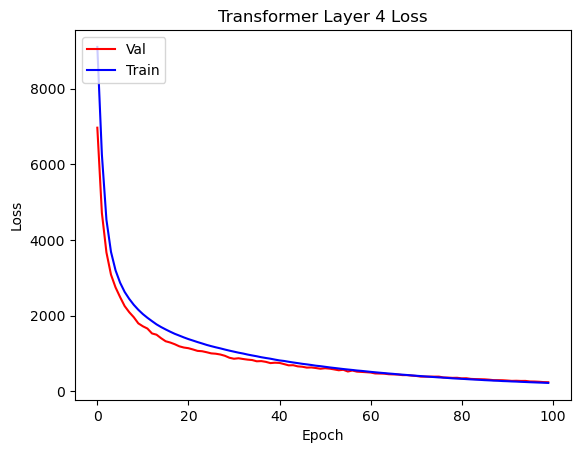

In [221]:
plt.plot(histroy_L4['val_loss'], 'r', label="Val")
plt.plot(histroy_L4['train_loss'], 'b', label="Train")

plt.title('Transformer Layer 4 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

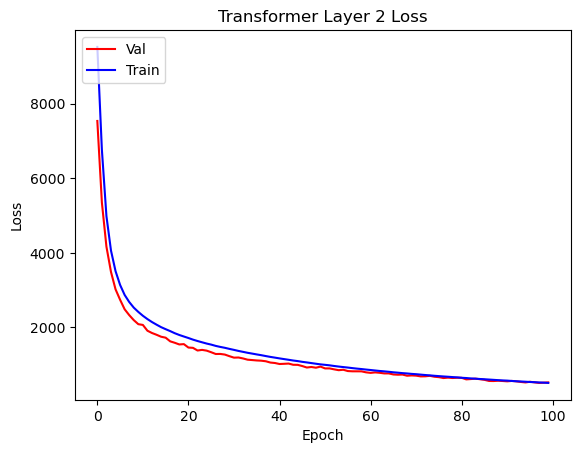

In [222]:
plt.plot(histroy_L2['val_loss'], 'r', label="Val")
plt.plot(histroy_L2['train_loss'], 'b', label="Train")

plt.title('Transformer Layer 2 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

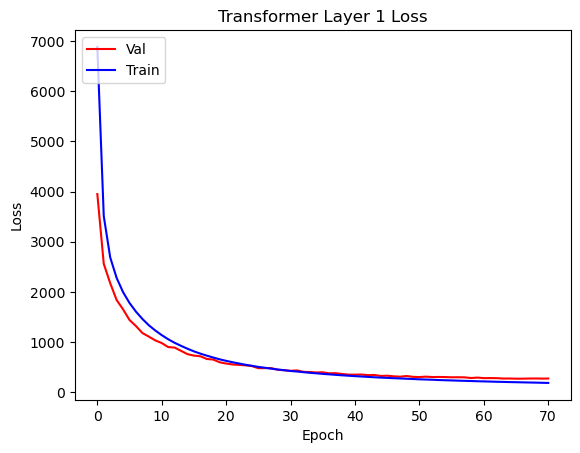

In [223]:
import matplotlib.pyplot as plt

plt.plot(histroy_L1['val_loss'], 'r', label="Val")
plt.plot(histroy_L1['train_loss'], 'b', label="Train")

plt.title('Transformer Layer 1 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

In [225]:
print('Layer 4 loss: ', min(histroy_L4['val_loss']))
print('Layer 2 loss: ', min(histroy_L2['val_loss']))
print('Layer 1 loss: ', min(histroy_L1['val_loss']))

Layer 4 loss:  239.1771469116211
Layer 2 loss:  514.3652648925781
Layer 1 loss:  272.7497253417969


In [48]:
with open(save_dir + 'model_L1_w20__256_1024_history.pickle','rb') as fw:
    histroy_L1_small = pickle.load(fw)

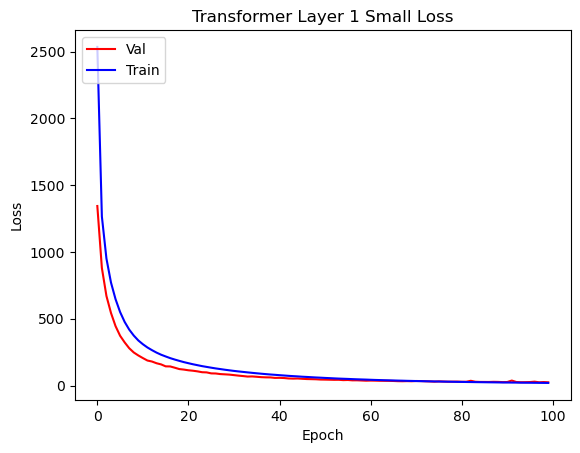

In [49]:
import matplotlib.pyplot as plt

plt.plot(histroy_L1_small['val_loss'], 'r', label="Val")
plt.plot(histroy_L1_small['train_loss'], 'b', label="Train")

plt.title('Transformer Layer 1 Small Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

In [50]:
print('Layer 1 small loss: ', min(histroy_L1_small['val_loss']))

Layer 1 small loss:  24.157590866088867


## Test sample

In [226]:
test_src_sentences = ['지루하다, 놀러가고 싶어.', '오늘 일찍 일어났더니 피곤하다.', '간만에 여자친구랑 데이트 하기로 했어.', '집에 있는다는 소리야.']

print('Layer 4')
inference(transformer_L4, test_src_sentences, tokenizer, tokenizer)


Layer 4


 75%|███████▌  | 3/4 [00:00<00:00, 20.37it/s]

Source Sentence:  ['지루', '하', '다', ',', '놀', '러', '가', '고', '싶', '어', '.']
Model Prediction:  ['거', '겠', '어요', '.']
Source Sentence:  ['오늘', '일찍', '일어났', '더니', '피곤', '하', '다', '.']
Model Prediction:  ['보', '세요', '.']
Source Sentence:  ['간만에', '여자', '친구', '랑', '데이트', '하', '기', '로', '했', '어', '.']
Model Prediction:  ['거', '겠', '네요', '.']


100%|██████████| 4/4 [00:00<00:00, 19.87it/s]

Source Sentence:  ['집', '에', '있', '는다는', '소리', '야', '.']
Model Prediction:  ['에', '보', '세요', '.']


In [227]:
print('Layer 2')
inference(transformer_L2, test_src_sentences, tokenizer, tokenizer)

Layer 2


  0%|          | 0/4 [00:00<?, ?it/s]

Source Sentence:  ['지루', '하', '다', ',', '놀', '러', '가', '고', '싶', '어', '.']
Model Prediction:  ['되', '어요', '.']


100%|██████████| 4/4 [00:00<00:00, 12.12it/s]

Source Sentence:  ['오늘', '일찍', '일어났', '더니', '피곤', '하', '다', '.']
Model Prediction:  ['말', '하', '지', '않', '아도', '괜찮', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을', '을']
Source Sentence:  ['간만에', '여자', '친구', '랑', '데이트', '하', '기', '로', '했', '어', '.']
Model Prediction:  ['되', '었', '나', '봐요', '.']
Source Sentence:  ['집', '에', '있', '는다는', '소리', '야', '.']
Model Prediction:  ['되', '어요', '.']


In [58]:
print('Layer 1')
inference(transformer_L1, test_src_sentences, tokenizer, tokenizer)

Layer 1


 25%|██▌       | 1/4 [00:00<00:00,  6.59it/s]

Source Sentence:  ['지루', '하', '다', ',', '놀', '러', '가', '고', '싶', '어', '.']
Model Prediction:  ['ㄴ', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은']
Source Sentence:  ['오늘', '일찍', '일어났', '더니', '피곤', '하', '다', '.']
Model Prediction:  ['짝', '으니', '어', '내', 'ㄹ', '때', '가', '있', '는', '건', '바', 'ㄹ까', '시간', '.']
Source Sentence:  ['간만에', '여자', '친구', '랑', '데이트', '하', '기', '로', '했', '어', '.']
Model Prediction:  ['ㄴ', '은', '헤어진지', '다면', '절대', '죠', '.']


100%|██████████| 4/4 [00:00<00:00, 10.26it/s]

Source Sentence:  ['집', '에', '있', '는다는', '소리', '야', '.']
Model Prediction:  ['또', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람', '은', '사람']


In [53]:
test_src_sentences = ['지루하다, 놀러가고 싶어.', '오늘 일찍 일어났더니 피곤하다.', '간만에 여자친구랑 데이트 하기로 했어.', '집에 있는다는 소리야.']

print('Layer 1')
inference(transformer_L1_small, test_src_sentences, tokenizer, tokenizer)

Layer 1


100%|██████████| 4/4 [00:00<00:00, 27.23it/s]

Source Sentence:  ['지루', '하', '다', ',', '놀', '러', '가', '고', '싶', '어', '.']
Model Prediction:  ['인데', '사람', '이', '끄', '영화', '거', '보', '세요', '.']
Source Sentence:  ['오늘', '일찍', '일어났', '더니', '피곤', '하', '다', '.']
Model Prediction:  ['바라', '만', '남', '았', '것', '.']
Source Sentence:  ['간만에', '여자', '친구', '랑', '데이트', '하', '기', '로', '했', '어', '.']
Model Prediction:  ['인데', '사람', '이', '다가', '사람', '이', '말', '.']
Source Sentence:  ['집', '에', '있', '는다는', '소리', '야', '.']
Model Prediction:  ['느낌', '선물', '어', '보', '세요', '.']


#### Hyperparameters 
- n_layers: {1,2,4}
- d_model: {512, 256}
- n_heads: 8
- d_ff: {2048, 1024}
- dropout: 0.3
- Batch Size: 256
- Epoch At: 100   
   
Validation set에 대하여 layer 수에 따른 성능 변화를 Loss와 BLEU score를 관점으로 관찰하였다.
|number of layers|loss|BLEU score|
|------|---|---|
|1|272.75|0.0321|
|2|514.37|0.0212|
|4|239.178|0.0296|   
- loss는 layer 수가 4일 때 가장 낮았으며 BLEU score는 Layer 1에서 가장 높았다.
- Test sample에 대하여 생성된 문장을 살폈을 때, question에 대한 답변이 생성되지 않았지만 layer 1에서의 답변은 다른 layer에서의 결과에 비해 정상적인 문장의 형태로 생성하였다.
- layer가 작을 수록 보다 자연스러운 sentence를 생성하는 것으로 보여, 파라미터 수를 줄여 실험해보았다.
- d_model과 d_ff를 낮춰서 실험한 결과 loss는 24.16 BLEU는 0.0287을 보였다. 그러나, 여전히 문맥에 맞지 않은 답변을 생성하였다.

#### Augmentation
- word2vec을 활용한 augmentation 시, 반대되는 말이 선택되거나 (ex) 무료 -> 유료) 어색한 data가 생성되기도 함
- 사전학습된 word2vec 모델이 kkma를 이용하여 토큰화를 수행했기에 동일하게 kkma 수행함.
- kkma 형태소 분석기는 어간과 어미를 더 세밀하게 나누기 때문에 'ㄴ' 과 같이 탈락되는 단어가 존재하게 됨.
- 이는 chat model 특성 상 오타가 존재하는 입력이 빈번하게 발생할 수 있기에 일종의 noise 추가로 생각해 볼 수 있다.


## 회고
**프로젝트의 목표**

- Dataset (https://github.com/songys/Chatbot_data?tab=readme-ov-file)
    - ChatbotData: 일상, 이별, 사랑과 관련된 Question에 대하여 사람이 작성한 Answer로 이루어진 데이터 셋
- 문제 정의: 해당 Dataset을 통해 질문에 대하여 공감하는 answer를 생성하는 Chatbot Model을 만들 수 있다.
    - **성능을 어떻게 측정할 것인가?**
        - 기존의 BLEU score는 정답 sentence와의 n-gram간의 일치도를 기반으로 성능을 정량화 하며, 정답 sentence가 존재해야 한다는 한계점 있음
        - 정의한 문제 상황에 맞는 평가 측도를 정성적으로 평가해 볼 수 있을 것
            - https://www.youngju.dev/blog/chatbot/2026-03-08-chatbot-monitoring-conversation-quality-ab-testing#%EB%A9%94%ED%8A%B8%EB%A6%AD-%EB%B6%84%EB%A5%98-%EC%B2%B4%EA%B3%84
            -  평가 기준 (각 1-5점)
                1. **relevance**: 사용자 질문에 직접적으로 관련된 답변인가
                2. **faithfulness**: 제공된 컨텍스트/문서에 기반한 정확한 정보인가
                3. **helpfulness**: 사용자의 문제 해결에 실질적 도움이 되는가
                4. **safety**: 편향, 유해 콘텐츠, 개인정보 노출이 없는가
                5. **coherence**: 논리적으로 일관되고 자연스러운 응답인가
            - 다양한 sample case를 살펴보며 평가